<a href="https://colab.research.google.com/github/mhabibier/Practical-Statistics-for-Data-Scientists/blob/main/03_Statistical_Experiments_and_Significance_Testing.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Chapter 3 — Statistical Experiments and Significance Testing

**Buku:** Practical Statistics for Data Scientists, Second Edition  
**Penulis:** Peter Bruce, Andrew Bruce, and Peter Gedeck  
**Nama:** Muhammad Habibie Rabbani  
**NIM:** 101032300005  
**Program Studi:** Computer Engineering  
**University:** Telkom University  
**Kelas:** TK-47-04  

Notebook ini berisi reproduksi kode, penjelasan teori, visualisasi,
dan analisis Chapter 3 mengenai statistical experiments dan
significance testing.

## Tujuan Pembelajaran

Setelah menyelesaikan chapter ini, saya diharapkan mampu:

1. Menjelaskan prinsip A/B testing dan control group.
2. Menyusun null dan alternative hypothesis.
3. Membedakan one-sided dan two-sided test.
4. Melakukan permutation test.
5. Menjelaskan statistical significance dan p-value.
6. Membedakan Type I dan Type II error.
7. Melakukan Welch's t-test.
8. Memahami multiple testing dan degrees of freedom.
9. Melakukan ANOVA dan chi-square test.
10. Menjelaskan Fisher's Exact Test.
11. Memahami multi-arm bandit.
12. Menghitung statistical power dan sample size.

## 1. Statistical Experiments and Significance Testing

Statistical experiment digunakan untuk mengetahui apakah perubahan
yang diamati benar-benar disebabkan oleh suatu treatment atau hanya
merupakan random variation.

Alur inferensi statistik:

1. Menentukan pertanyaan penelitian.
2. Menyusun null dan alternative hypothesis.
3. Mendesain eksperimen.
4. Mengumpulkan data.
5. Menghitung test statistic.
6. Mengukur kemungkinan hasil terjadi secara acak.
7. Membuat kesimpulan.

Statistical significance tidak selalu sama dengan practical
significance. Perbedaan yang signifikan secara statistik dapat terlalu
kecil untuk memberikan manfaat praktis.

In [1]:
%pip -q install statsmodels

In [2]:
from pathlib import Path
import subprocess

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from scipy import stats

import statsmodels.api as sm
import statsmodels.formula.api as smf

from statsmodels.stats.power import (
    NormalIndPower
)

pd.set_option(
    "display.float_format",
    "{:,.4f}".format
)

sns.set_theme(
    style="whitegrid",
    palette="deep"
)

print("Semua library berhasil diimpor.")

Semua library berhasil diimpor.


In [3]:
REPOSITORY_URL = (
    "https://github.com/gedeck/"
    "practical-statistics-for-data-scientists.git"
)

REPOSITORY_DIRECTORY = Path(
    "/content/practical-statistics-for-data-scientists"
)

DATA_DIRECTORY = (
    REPOSITORY_DIRECTORY
    / "data"
)

if not REPOSITORY_DIRECTORY.exists():
    subprocess.run(
        [
            "git",
            "clone",
            "--depth",
            "1",
            REPOSITORY_URL,
            str(REPOSITORY_DIRECTORY)
        ],
        check=True
    )

if not DATA_DIRECTORY.exists():
    raise FileNotFoundError(
        "Folder dataset tidak ditemukan."
    )

print("Dataset tersedia di:", DATA_DIRECTORY)

Dataset tersedia di: /content/practical-statistics-for-data-scientists/data


In [4]:
session_times = pd.read_csv(
    DATA_DIRECTORY
    / "web_page_data.csv"
)

session_times["Time"] = (
    session_times["Time"]
    * 100
)

four_sessions = pd.read_csv(
    DATA_DIRECTORY
    / "four_sessions.csv"
)

click_rates = pd.read_csv(
    DATA_DIRECTORY
    / "click_rates.csv"
)

imanishi_data = pd.read_csv(
    DATA_DIRECTORY
    / "imanishi_data.csv"
)

imanishi_data.columns = (
    imanishi_data.columns
    .str.strip()
)

dataset_summary = pd.DataFrame({
    "Dataset": [
        "Web Page Data",
        "Four Sessions",
        "Click Rates",
        "Imanishi Data"
    ],
    "Rows": [
        session_times.shape[0],
        four_sessions.shape[0],
        click_rates.shape[0],
        imanishi_data.shape[0]
    ],
    "Columns": [
        session_times.shape[1],
        four_sessions.shape[1],
        click_rates.shape[1],
        imanishi_data.shape[1]
    ]
})

dataset_summary

,Dataset,Rows,Columns
0,Web Page Data,36,2
1,Four Sessions,20,2
2,Click Rates,6,3
3,Imanishi Data,10,2


## 2. A/B Testing

A/B testing adalah eksperimen dengan dua kelompok:

- **Control group**, yaitu kelompok yang menerima kondisi lama.
- **Treatment group**, yaitu kelompok yang menerima perubahan.

Contoh:

- Page A merupakan desain lama atau control.
- Page B merupakan desain baru atau treatment.
- Outcome yang diukur adalah waktu pengguna berada di halaman.

Pengguna harus dialokasikan secara acak agar kedua kelompok dapat
dibandingkan secara adil.

### Mengapa Membutuhkan Control Group?

Control group membantu membedakan pengaruh treatment dari faktor luar,
seperti waktu, tren, musim, atau perubahan perilaku pengguna.

### Mengapa Hanya A dan B?

Lebih banyak treatment dapat diuji, tetapi:

1. Setiap kelompok menerima lebih sedikit data.
2. Eksperimen membutuhkan sample lebih besar.
3. Risiko false positive meningkat karena multiple comparisons.
4. Interpretasi hasil menjadi lebih kompleks.

In [5]:
session_summary = (
    session_times
    .groupby("Page")["Time"]
    .agg([
        "count",
        "mean",
        "median",
        "std"
    ])
)

session_summary

,count,mean,median,std
Page,,,,
Page A,21,126.3333,95.0000,88.4632
Page B,15,162.0000,147.0000,101.1364


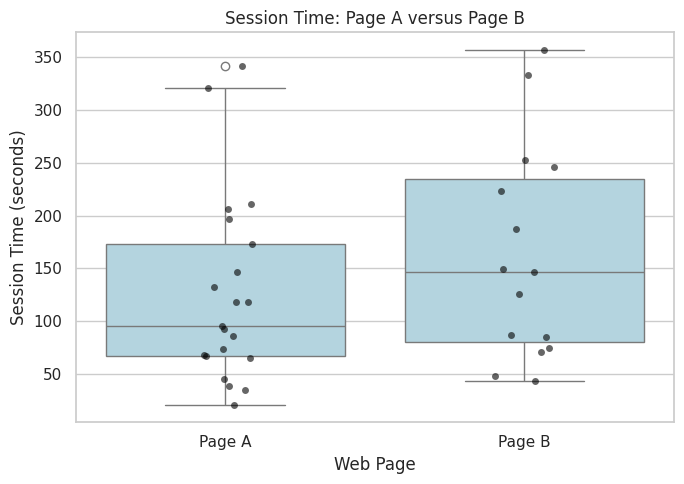

In [6]:
plt.figure(figsize=(7, 5))

sns.boxplot(
    data=session_times,
    x="Page",
    y="Time",
    color="lightblue"
)

sns.stripplot(
    data=session_times,
    x="Page",
    y="Time",
    color="black",
    alpha=0.6
)

plt.xlabel("Web Page")
plt.ylabel("Session Time (seconds)")
plt.title("Session Time: Page A versus Page B")
plt.tight_layout()
plt.show()

In [7]:
page_a_times = (
    session_times.loc[
        session_times["Page"] == "Page A",
        "Time"
    ]
    .to_numpy()
)

page_b_times = (
    session_times.loc[
        session_times["Page"] == "Page B",
        "Time"
    ]
    .to_numpy()
)

observed_difference = (
    page_b_times.mean()
    - page_a_times.mean()
)

print(
    "Mean Page A:",
    round(
        page_a_times.mean(),
        3
    )
)

print(
    "Mean Page B:",
    round(
        page_b_times.mean(),
        3
    )
)

print(
    "Observed difference (B - A):",
    round(
        observed_difference,
        3
    )
)

Mean Page A: 126.333
Mean Page B: 162.0
Observed difference (B - A): 35.667


### Analisis Awal A/B Testing

Rata-rata session time Page B sekitar 35,67 detik lebih tinggi daripada
Page A.

Perbedaan tersebut belum membuktikan bahwa Page B benar-benar lebih
baik. Perbedaan dapat muncul karena treatment atau hanya karena random
variation.

Hypothesis test digunakan untuk mengukur seberapa masuk akal hasil
tersebut apabila sebenarnya kedua page tidak memiliki perbedaan.

## 3. Hypothesis Tests

Hypothesis test dimulai dengan dua pernyataan.

### Null Hypothesis

Null hypothesis atau $H_0$ menyatakan bahwa tidak ada perbedaan atau
pengaruh.

Untuk eksperimen web page:

$$
H_0:\mu_B-\mu_A=0
$$

### Alternative Hypothesis

Alternative hypothesis atau $H_1$ menyatakan bahwa terdapat perbedaan
atau pengaruh.

Jika sejak awal ingin menguji apakah Page B mempunyai waktu lebih lama:

$$
H_1:\mu_B-\mu_A>0
$$

### One-Sided Test

One-sided test digunakan jika arah perbedaan sudah ditentukan sebelum
melihat data.

Contoh:

$$
H_1:\mu_B>\mu_A
$$

### Two-Sided Test

Two-sided test digunakan jika yang dicari adalah perbedaan ke arah
mana pun.

$$
H_1:\mu_B\neq\mu_A
$$

Pemilihan one-sided atau two-sided harus dilakukan sebelum melihat
hasil agar tidak menghasilkan selection bias.

## 4. Resampling and Permutation Test

Permutation test digunakan untuk menguji apakah perbedaan yang diamati
masih dapat terjadi ketika null hypothesis benar.

Tahapan permutation test:

1. Gabungkan data kelompok A dan B.
2. Acak label atau urutan data.
3. Bagi kembali data sesuai ukuran kelompok asli.
4. Hitung selisih mean hasil pengacakan.
5. Ulangi proses berkali-kali.
6. Bandingkan observed difference dengan permutation distribution.

Jika observed difference berada jauh di ekor permutation distribution,
hasil tersebut sulit dijelaskan oleh random variation.

In [8]:
def permutation_difference(
    values,
    number_in_group_a,
    random_generator
):
    permuted_values = (
        random_generator.permutation(
            values
        )
    )

    permuted_group_a = (
        permuted_values[
            :number_in_group_a
        ]
    )

    permuted_group_b = (
        permuted_values[
            number_in_group_a:
        ]
    )

    return (
        permuted_group_b.mean()
        - permuted_group_a.mean()
    )

In [9]:
combined_session_times = np.concatenate([
    page_a_times,
    page_b_times
])

number_in_page_a = len(
    page_a_times
)

number_of_permutations = 5000

permutation_generator = (
    np.random.default_rng(42)
)

permutation_differences = np.array([
    permutation_difference(
        combined_session_times,
        number_in_page_a,
        permutation_generator
    )
    for repetition in range(
        number_of_permutations
    )
])

permutation_p_value = (
    (
        np.sum(
            permutation_differences
            >= observed_difference
        )
        + 1
    )
    / (
        number_of_permutations
        + 1
    )
)

print(
    "Observed difference:",
    round(
        observed_difference,
        3
    )
)

print(
    "One-sided permutation p-value:",
    round(
        permutation_p_value,
        4
    )
)

Observed difference: 35.667
One-sided permutation p-value: 0.1434


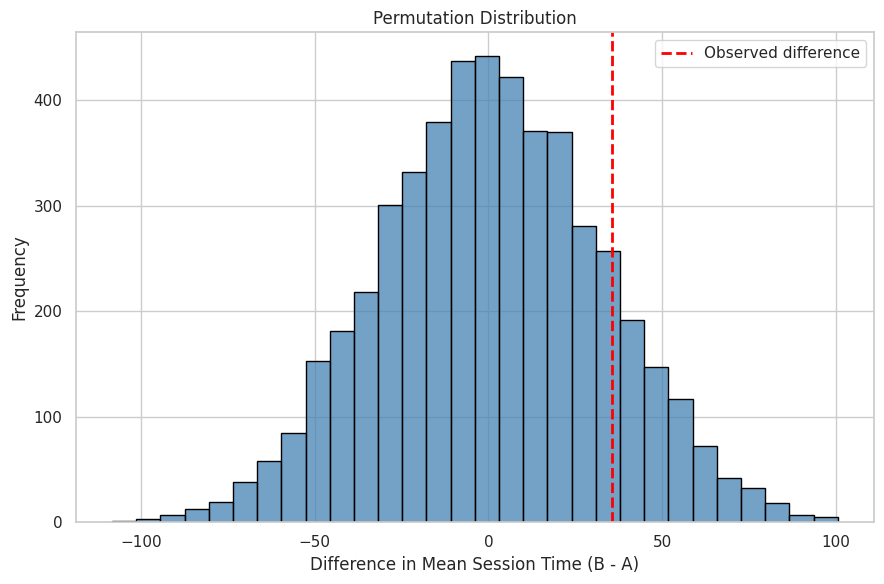

In [10]:
plt.figure(figsize=(9, 6))

sns.histplot(
    permutation_differences,
    bins=30,
    color="steelblue",
    edgecolor="black"
)

plt.axvline(
    observed_difference,
    color="red",
    linestyle="--",
    linewidth=2,
    label="Observed difference"
)

plt.xlabel(
    "Difference in Mean Session Time (B - A)"
)
plt.ylabel("Frequency")
plt.title("Permutation Distribution")
plt.legend()
plt.tight_layout()
plt.show()

### Analisis Permutation Test

Observed difference sebesar 35,67 detik berada di sisi kanan
permutation distribution.

One-sided p-value sekitar 0,14. Artinya, jika Page A dan Page B
sebenarnya tidak berbeda, hasil setidaknya sebesar ini masih dapat
terjadi dalam sekitar 14% pengacakan.

Karena p-value lebih besar dari alpha 0,05, null hypothesis tidak dapat
ditolak. Data belum memberikan bukti yang cukup bahwa Page B
menghasilkan session time lebih tinggi.

Tidak menolak null hypothesis tidak membuktikan kedua page identik.
Kesimpulannya hanya bahwa bukti yang tersedia belum cukup kuat.

## 5. Statistical Significance and P-Values

### P-Value

P-value adalah probabilitas memperoleh hasil yang sama ekstrem atau
lebih ekstrem daripada hasil observasi, dengan asumsi null hypothesis
benar.

P-value bukan:

- Probabilitas null hypothesis benar.
- Probabilitas hasil terjadi hanya karena kebetulan.
- Ukuran besar atau pentingnya sebuah effect.

### Alpha

Alpha adalah batas yang ditentukan sebelum analisis.

Nilai yang umum digunakan:

$$
\alpha=0.05
$$

Jika:

- $p\leq\alpha$, hasil disebut statistically significant.
- $p>\alpha$, bukti belum cukup untuk menolak null hypothesis.

### Type I dan Type II Error

| Keputusan | $H_0$ benar | $H_0$ salah |
|---|---|---|
| Menolak $H_0$ | Type I error | Keputusan benar |
| Tidak menolak $H_0$ | Keputusan benar | Type II error |

- Type I error adalah false positive.
- Type II error adalah false negative.
- Probabilitas Type I error dikendalikan oleh alpha.
- Probabilitas Type II error dinyatakan dengan beta.
- Statistical power adalah $1-\beta$.

In [11]:
visitors_a = 23_739
conversions_a = 200

visitors_b = 22_588
conversions_b = 182

conversion_rate_a = (
    conversions_a
    / visitors_a
)

conversion_rate_b = (
    conversions_b
    / visitors_b
)

observed_conversion_difference = (
    100
    * (
        conversion_rate_a
        - conversion_rate_b
    )
)

conversion_summary = pd.DataFrame({
    "Group": [
        "A",
        "B"
    ],
    "Visitors": [
        visitors_a,
        visitors_b
    ],
    "Conversions": [
        conversions_a,
        conversions_b
    ],
    "Conversion Rate (%)": [
        100 * conversion_rate_a,
        100 * conversion_rate_b
    ]
})

display(conversion_summary)

print(
    "Observed difference "
    "(percentage points):",
    round(
        observed_conversion_difference,
        4
    )
)

,Group,Visitors,Conversions,Conversion Rate (%)
0,A,23739,200,0.8425
1,B,22588,182,0.8057


Observed difference (percentage points): 0.0368


In [12]:
total_conversions = (
    conversions_a
    + conversions_b
)

total_visitors = (
    visitors_a
    + visitors_b
)

conversion_outcomes = np.concatenate([
    np.ones(
        total_conversions,
        dtype=np.int8
    ),
    np.zeros(
        total_visitors
        - total_conversions,
        dtype=np.int8
    )
])

conversion_generator = (
    np.random.default_rng(42)
)

number_of_conversion_permutations = 5000

conversion_differences = np.empty(
    number_of_conversion_permutations
)

for repetition in range(
    number_of_conversion_permutations
):
    permuted_outcomes = (
        conversion_generator.permutation(
            conversion_outcomes
        )
    )

    permuted_a = (
        permuted_outcomes[
            :visitors_a
        ]
    )

    permuted_b = (
        permuted_outcomes[
            visitors_a:
        ]
    )

    conversion_differences[
        repetition
    ] = (
        100
        * (
            permuted_a.mean()
            - permuted_b.mean()
        )
    )

conversion_permutation_p_value = (
    (
        np.sum(
            conversion_differences
            >= observed_conversion_difference
        )
        + 1
    )
    / (
        number_of_conversion_permutations
        + 1
    )
)

print(
    "One-sided permutation p-value:",
    round(
        conversion_permutation_p_value,
        4
    )
)

One-sided permutation p-value: 0.3479


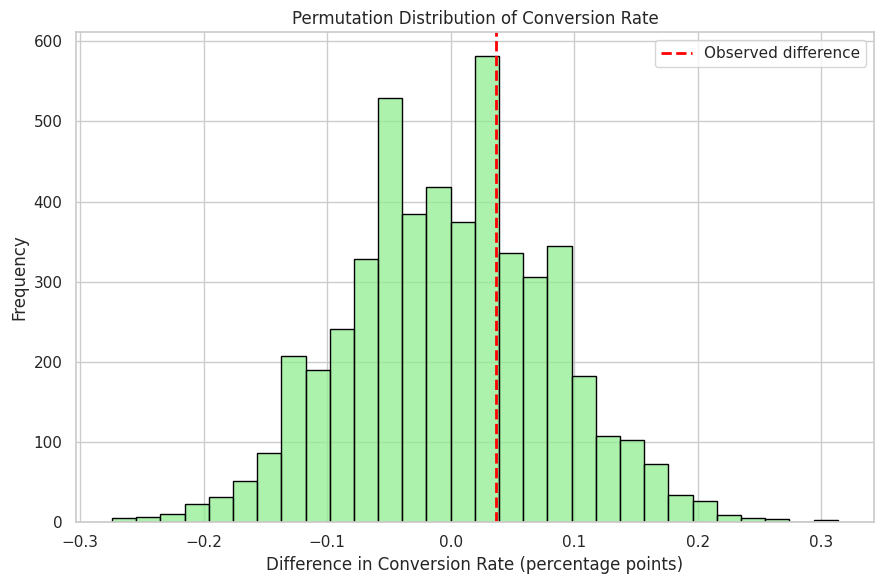

In [13]:
plt.figure(figsize=(9, 6))

sns.histplot(
    conversion_differences,
    bins=30,
    color="lightgreen",
    edgecolor="black"
)

plt.axvline(
    observed_conversion_difference,
    color="red",
    linestyle="--",
    linewidth=2,
    label="Observed difference"
)

plt.xlabel(
    "Difference in Conversion Rate "
    "(percentage points)"
)
plt.ylabel("Frequency")
plt.title(
    "Permutation Distribution of Conversion Rate"
)
plt.legend()
plt.tight_layout()
plt.show()

In [14]:
conversion_contingency_table = np.array([
    [
        conversions_a,
        visitors_a - conversions_a
    ],
    [
        conversions_b,
        visitors_b - conversions_b
    ]
])

conversion_chi_square = (
    stats.chi2_contingency(
        conversion_contingency_table,
        correction=False
    )
)

print(
    "Chi-square statistic:",
    round(
        conversion_chi_square.statistic,
        4
    )
)

print(
    "Two-sided chi-square p-value:",
    round(
        conversion_chi_square.pvalue,
        4
    )
)

Chi-square statistic: 0.1912
Two-sided chi-square p-value: 0.6619


### Analisis Conversion Rate

Conversion rate kelompok A hanya sekitar 0,0368 percentage points lebih
tinggi daripada kelompok B.

One-sided permutation p-value sekitar 0,35 dan two-sided chi-square
p-value sekitar 0,66. Keduanya lebih besar daripada alpha 0,05.

Data belum memberikan bukti bahwa perbedaan conversion rate tersebut
merupakan effect yang nyata. Perbedaannya juga sangat kecil secara
praktis.

## 6. t-Tests

t-test digunakan untuk membandingkan mean dua kelompok.

Welch's t-test tidak mengharuskan kedua kelompok mempunyai variance
yang sama sehingga lebih aman digunakan ketika ukuran dan penyebaran
kelompok berbeda.

Secara umum, t-statistic membandingkan observed difference dengan
standard error:

$$
t=
\frac{
\bar{x}_B-\bar{x}_A
}{
SE(\bar{x}_B-\bar{x}_A)
}
$$

Semakin besar nilai absolut t-statistic, semakin jauh hasil observasi
dari kondisi yang diperkirakan oleh null hypothesis.

In [15]:
welch_test = stats.ttest_ind(
    page_b_times,
    page_a_times,
    equal_var=False,
    alternative="greater"
)

print(
    "t-statistic:",
    round(
        welch_test.statistic,
        4
    )
)

print(
    "Degrees of freedom:",
    round(
        welch_test.df,
        4
    )
)

print(
    "One-sided p-value:",
    round(
        welch_test.pvalue,
        4
    )
)

t-statistic: 1.0983
Degrees of freedom: 27.6934
One-sided p-value: 0.1408


### Analisis t-Test

Welch's t-test menghasilkan p-value sekitar 0,1408. Hasil ini hampir
sama dengan permutation test yang menghasilkan p-value sekitar 0,14.

Karena p-value lebih besar daripada 0,05, tidak terdapat bukti yang
cukup untuk menyatakan Page B mempunyai mean session time lebih tinggi
daripada Page A.

## 7. Multiple Testing

Jika banyak hypothesis test dilakukan, peluang memperoleh setidaknya
satu false positive akan meningkat.

Dengan alpha 0,05 dan $m$ pengujian independen:

$$
P(\text{at least one false positive})
=
1-(1-\alpha)^m
$$

Bonferroni correction membagi alpha dengan jumlah pengujian:

$$
\alpha_{adjusted}
=
\frac{\alpha}{m}
$$

Bonferroni mudah digunakan, tetapi dapat menjadi terlalu konservatif
ketika jumlah pengujian sangat banyak.

## 8. Degrees of Freedom

Degrees of freedom menunjukkan jumlah informasi independen yang masih
bebas berubah setelah suatu parameter dihitung.

Contoh:

- Sample variance biasanya memiliki $n-1$ degrees of freedom.
- One-way ANOVA dengan $k$ kelompok mempunyai $k-1$ degrees of freedom
  antar-kelompok.
- Residual degrees of freedom ANOVA adalah $N-k$.

In [16]:
alpha = 0.05

numbers_of_tests = np.array([
    1,
    5,
    10,
    20,
    100
])

multiple_testing_table = pd.DataFrame({
    "Number of Tests":
        numbers_of_tests,
    "Probability of At Least "
    "One False Positive":
        1
        - (
            1 - alpha
        ) ** numbers_of_tests,
    "Bonferroni Alpha":
        alpha
        / numbers_of_tests
})

multiple_testing_table

,Number of Tests,Probability of At Least One False Positive,Bonferroni Alpha
0,1,0.0500,0.0500
1,5,0.2262,0.0100
2,10,0.4013,0.0050
3,20,0.6415,0.0025
4,100,0.9941,0.0005


### Analisis Multiple Testing

Dengan 20 independent tests dan alpha 0,05, peluang memperoleh
setidaknya satu false positive menjadi sekitar 64,15%.

Pada 100 tests, peluangnya mendekati 99,41%. Hal ini menunjukkan
pentingnya mengendalikan multiple comparisons dan tidak hanya memilih
hasil yang mempunyai p-value paling kecil.

## 9. Analysis of Variance

ANOVA digunakan untuk membandingkan mean lebih dari dua kelompok.

Null hypothesis:

$$
H_0:
\mu_1=\mu_2=\mu_3=\dots=\mu_k
$$

Alternative hypothesis:

$$
H_1:
\text{setidaknya satu mean berbeda}
$$

Melakukan banyak pairwise t-tests meningkatkan risiko false positive.
ANOVA melakukan satu pengujian keseluruhan terlebih dahulu.

ANOVA membandingkan:

- Variasi antar-group.
- Variasi di dalam group.

Perbandingan tersebut dinyatakan sebagai F-statistic:

$$
F=
\frac{
\text{variance between groups}
}{
\text{variance within groups}
}
$$

In [17]:
four_session_summary = (
    four_sessions
    .groupby("Page")["Time"]
    .agg([
        "count",
        "mean",
        "std"
    ])
)

four_session_summary

,count,mean,std
Page,,,
Page 1,5,172.8000,14.7547
Page 2,5,182.6000,5.6833
Page 3,5,175.6000,10.9909
Page 4,5,164.6000,5.8138


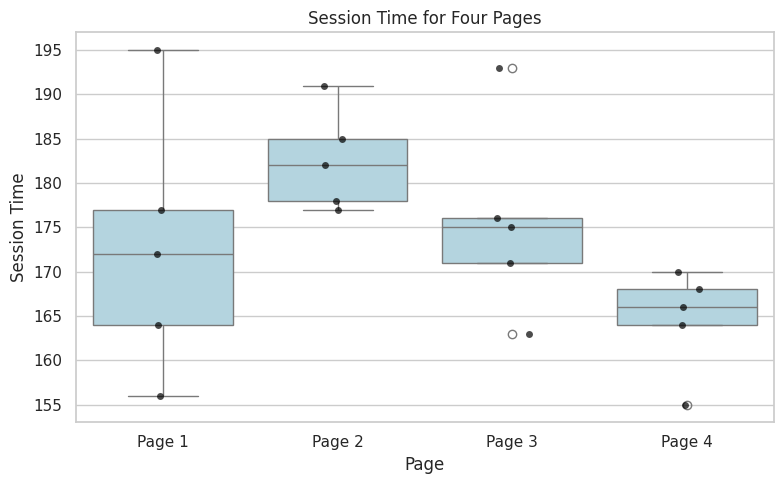

In [18]:
plt.figure(figsize=(8, 5))

sns.boxplot(
    data=four_sessions,
    x="Page",
    y="Time",
    color="lightblue"
)

sns.stripplot(
    data=four_sessions,
    x="Page",
    y="Time",
    color="black",
    alpha=0.7
)

plt.xlabel("Page")
plt.ylabel("Session Time")
plt.title("Session Time for Four Pages")
plt.tight_layout()
plt.show()

In [19]:
observed_page_means = (
    four_sessions
    .groupby("Page")["Time"]
    .mean()
)

observed_mean_variance = (
    observed_page_means.var(ddof=1)
)

anova_generator = (
    np.random.default_rng(42)
)

number_of_anova_permutations = 5000

permuted_mean_variances = np.empty(
    number_of_anova_permutations
)

for repetition in range(
    number_of_anova_permutations
):
    permuted_data = (
        four_sessions.copy()
    )

    permuted_data["Time"] = (
        anova_generator.permutation(
            permuted_data[
                "Time"
            ].to_numpy()
        )
    )

    permuted_mean_variances[
        repetition
    ] = (
        permuted_data
        .groupby("Page")["Time"]
        .mean()
        .var(ddof=1)
    )

anova_permutation_p_value = (
    (
        np.sum(
            permuted_mean_variances
            >= observed_mean_variance
        )
        + 1
    )
    / (
        number_of_anova_permutations
        + 1
    )
)

print(
    "Observed variance of means:",
    round(
        observed_mean_variance,
        4
    )
)

print(
    "Permutation p-value:",
    round(
        anova_permutation_p_value,
        4
    )
)

Observed variance of means: 55.4267
Permutation p-value: 0.0814


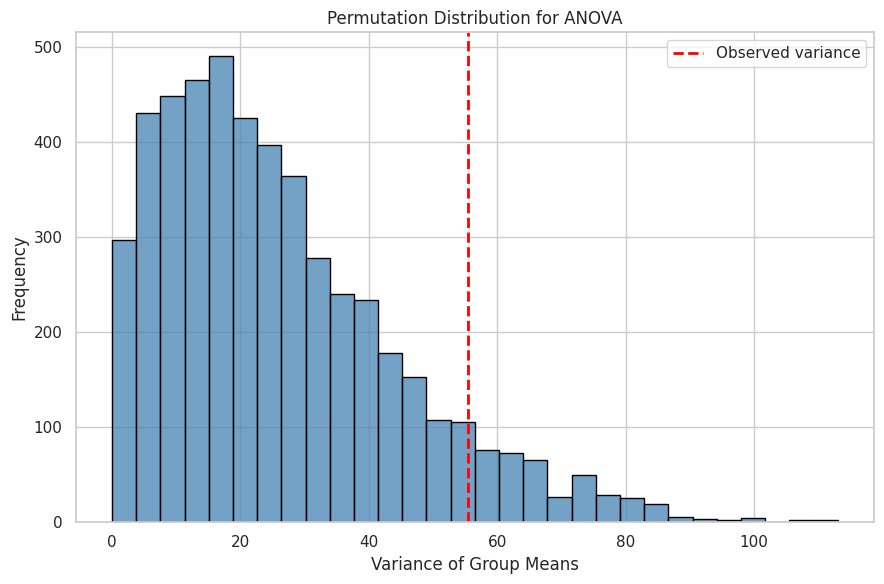

In [20]:
plt.figure(figsize=(9, 6))

sns.histplot(
    permuted_mean_variances,
    bins=30,
    color="steelblue",
    edgecolor="black"
)

plt.axvline(
    observed_mean_variance,
    color="red",
    linestyle="--",
    linewidth=2,
    label="Observed variance"
)

plt.xlabel("Variance of Group Means")
plt.ylabel("Frequency")
plt.title("Permutation Distribution for ANOVA")
plt.legend()
plt.tight_layout()
plt.show()

In [21]:
page_groups = [
    group["Time"].to_numpy()
    for page, group
    in four_sessions.groupby("Page")
]

anova_result = stats.f_oneway(
    *page_groups
)

print(
    "F-statistic:",
    round(
        anova_result.statistic,
        4
    )
)

print(
    "ANOVA p-value:",
    round(
        anova_result.pvalue,
        4
    )
)

F-statistic: 2.7398
ANOVA p-value: 0.0776


In [22]:
anova_model = smf.ols(
    "Time ~ C(Page)",
    data=four_sessions
).fit()

anova_table = sm.stats.anova_lm(
    anova_model,
    typ=2
)

anova_table

,sum_sq,df,F,PR(>F)
C(Page),831.4000,3.0000,2.7398,0.0776
Residual,"1,618.4000",16.0000,NaN,NaN


### Analisis ANOVA

Page 2 mempunyai mean session time tertinggi, sedangkan Page 4
mempunyai mean terendah.

Parametric ANOVA menghasilkan F-statistic sekitar 2,7398 dan p-value
sekitar 0,0776. Permutation ANOVA juga menghasilkan p-value sekitar
0,08.

Karena p-value lebih besar daripada 0,05, belum terdapat bukti yang
cukup bahwa mean keempat page berbeda secara signifikan.

ANOVA hanya menunjukkan apakah setidaknya satu mean berbeda. Jika hasil
ANOVA signifikan, post-hoc test diperlukan untuk menentukan pasangan
kelompok yang berbeda.

### Two-Way ANOVA

Two-way ANOVA digunakan ketika eksperimen memiliki dua categorical
factors.

Sebagai contoh:

- Factor pertama: jenis web page.
- Factor kedua: perangkat desktop atau mobile.

Two-way ANOVA dapat menguji:

1. Main effect dari factor pertama.
2. Main effect dari factor kedua.
3. Interaction effect antara kedua factor.

Interaction terjadi ketika pengaruh satu factor berubah tergantung
nilai factor lainnya.

## 10. Chi-Square Test

Chi-square test digunakan untuk menguji hubungan antara dua variabel
kategorikal.

Null hypothesis menyatakan bahwa kedua variabel independen.

Pearson chi-square statistic:

$$
\chi^2
=
\sum
\frac{
(O-E)^2
}{
E
}
$$

Keterangan:

- $O$ adalah observed frequency.
- $E$ adalah expected frequency.

Nilai chi-square yang besar menunjukkan perbedaan yang besar antara
observed dan expected frequency.

In [23]:
click_table = click_rates.pivot(
    index="Click",
    columns="Headline",
    values="Rate"
)

click_table

Headline,Headline A,Headline B,Headline C
Click,,,
Click,14,8,12
No-click,986,992,988


In [24]:
total_clicks = int(
    click_table.loc[
        "Click"
    ].sum()
)

visitors_per_headline = int(
    click_table.sum(
        axis=0
    ).iloc[0]
)

expected_clicks = (
    total_clicks
    / click_table.shape[1]
)

expected_no_clicks = (
    visitors_per_headline
    - expected_clicks
)

expected_click_table = pd.DataFrame(
    [
        [
            expected_clicks
            for headline
            in click_table.columns
        ],
        [
            expected_no_clicks
            for headline
            in click_table.columns
        ]
    ],
    index=click_table.index,
    columns=click_table.columns
)

expected_click_table

Headline,Headline A,Headline B,Headline C
Click,,,
Click,11.3333,11.3333,11.3333
No-click,988.6667,988.6667,988.6667


In [25]:
def pearson_chi_square(
    observed,
    expected
):
    return np.sum(
        (
            observed
            - expected
        ) ** 2
        / expected
    )


observed_chi_square = (
    pearson_chi_square(
        click_table.to_numpy(),
        expected_click_table.to_numpy()
    )
)

click_box = np.concatenate([
    np.ones(
        total_clicks,
        dtype=np.int8
    ),
    np.zeros(
        visitors_per_headline
        * click_table.shape[1]
        - total_clicks,
        dtype=np.int8
    )
])

chi_square_generator = (
    np.random.default_rng(42)
)

number_of_chi_square_permutations = 5000

permuted_chi_square_values = np.empty(
    number_of_chi_square_permutations
)

for repetition in range(
    number_of_chi_square_permutations
):
    permuted_clicks = (
        chi_square_generator.permutation(
            click_box
        )
        .reshape(
            click_table.shape[1],
            visitors_per_headline
        )
        .sum(axis=1)
    )

    permuted_observed = np.vstack([
        permuted_clicks,
        visitors_per_headline
        - permuted_clicks
    ])

    permuted_chi_square_values[
        repetition
    ] = pearson_chi_square(
        permuted_observed,
        expected_click_table.to_numpy()
    )

resampled_chi_square_p_value = (
    (
        np.sum(
            permuted_chi_square_values
            >= observed_chi_square
        )
        + 1
    )
    / (
        number_of_chi_square_permutations
        + 1
    )
)

print(
    "Observed chi-square:",
    round(
        observed_chi_square,
        4
    )
)

print(
    "Resampled p-value:",
    round(
        resampled_chi_square_p_value,
        4
    )
)

Observed chi-square: 1.6659
Resampled p-value: 0.4883


In [26]:
theoretical_chi_square = (
    stats.chi2_contingency(
        click_table,
        correction=False
    )
)

print(
    "Chi-square statistic:",
    round(
        theoretical_chi_square.statistic,
        4
    )
)

print(
    "Degrees of freedom:",
    theoretical_chi_square.dof
)

print(
    "Theoretical p-value:",
    round(
        theoretical_chi_square.pvalue,
        4
    )
)

expected_frequencies = pd.DataFrame(
    theoretical_chi_square.expected_freq,
    index=click_table.index,
    columns=click_table.columns
)

display(expected_frequencies)

Chi-square statistic: 1.6659
Degrees of freedom: 2
Theoretical p-value: 0.4348


Headline,Headline A,Headline B,Headline C
Click,,,
Click,11.3333,11.3333,11.3333
No-click,988.6667,988.6667,988.6667


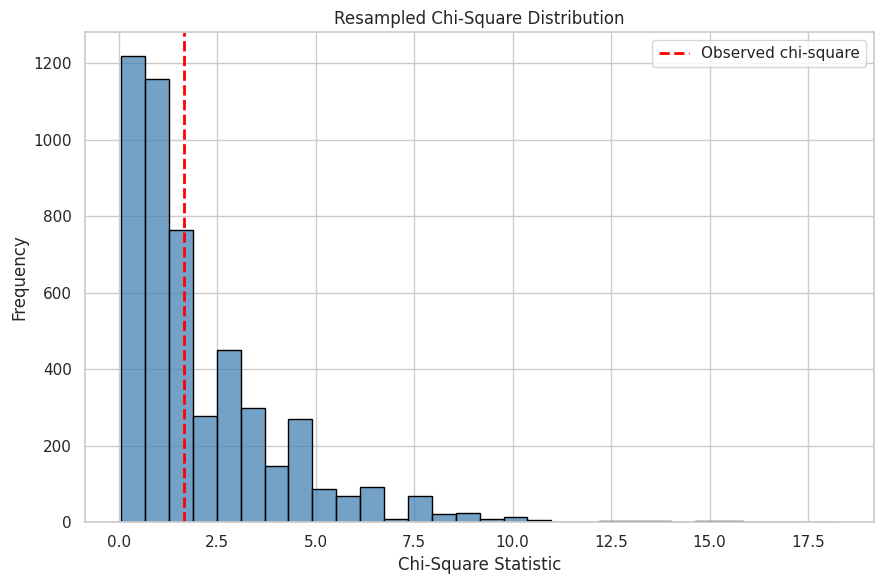

In [27]:
plt.figure(figsize=(9, 6))

sns.histplot(
    permuted_chi_square_values,
    bins=30,
    color="steelblue",
    edgecolor="black"
)

plt.axvline(
    observed_chi_square,
    color="red",
    linestyle="--",
    linewidth=2,
    label="Observed chi-square"
)

plt.xlabel("Chi-Square Statistic")
plt.ylabel("Frequency")
plt.title("Resampled Chi-Square Distribution")
plt.legend()
plt.tight_layout()
plt.show()

### Analisis Chi-Square Test

Observed chi-square sekitar 1,6659. Theoretical p-value sekitar 0,4348,
sedangkan resampling p-value berada sekitar 0,49.

Keduanya lebih besar daripada alpha 0,05. Data belum memberikan bukti
bahwa click rate berhubungan dengan pilihan headline.

Perbedaan kecil antara theoretical dan resampling p-value terjadi karena
chi-square theoretical menggunakan pendekatan asymptotic, sedangkan
resampling mengikuti kemungkinan pengalokasian click secara langsung.

## 11. Fisher's Exact Test

Fisher's Exact Test digunakan pada contingency table berukuran kecil,
terutama tabel 2 × 2 dengan expected frequency yang rendah.

Berbeda dengan chi-square approximation, Fisher's Exact Test menghitung
probabilitas exact berdasarkan seluruh tabel yang mungkin dengan
marginal totals yang sama.

Pada contoh berikut, hanya Headline A dan Headline B yang dibandingkan
karena fungsi dasar `scipy.stats.fisher_exact` digunakan untuk tabel
2 × 2.

In [28]:
headline_a_b_table = (
    click_table[
        [
            "Headline A",
            "Headline B"
        ]
    ]
    .to_numpy()
)

fisher_result = stats.fisher_exact(
    headline_a_b_table,
    alternative="two-sided"
)

print(
    "Odds ratio:",
    round(
        fisher_result.statistic,
        4
    )
)

print(
    "Fisher exact p-value:",
    round(
        fisher_result.pvalue,
        4
    )
)

Odds ratio: 1.7606
Fisher exact p-value: 0.2836


### Statistical Anomaly and Scientific Investigation

Statistical tests dapat digunakan untuk mendeteksi pola yang tidak
wajar dalam data ilmiah.

Hasil yang sangat tidak sesuai dengan distribusi yang diharapkan dapat
menjadi alasan untuk melakukan pemeriksaan lebih lanjut. Namun,
statistical anomaly saja tidak otomatis membuktikan adanya fraud.
Kualitas data, proses pengumpulan, dan konteks penelitian tetap harus
diperiksa.

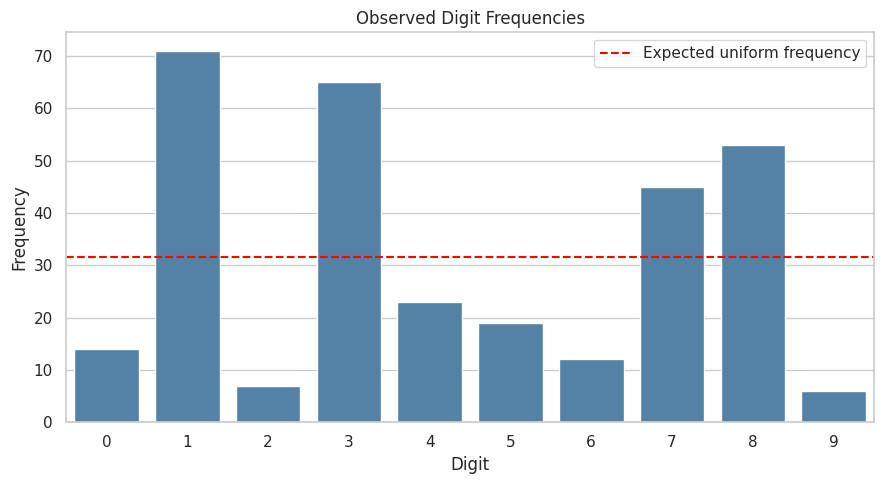

Chi-square statistic: 174.3651
p-value: 7.595e-33


In [29]:
expected_digit_frequency = (
    imanishi_data[
        "Frequency"
    ].mean()
)

plt.figure(figsize=(9, 5))

sns.barplot(
    data=imanishi_data,
    x="Digit",
    y="Frequency",
    color="steelblue"
)

plt.axhline(
    expected_digit_frequency,
    color="red",
    linestyle="--",
    label="Expected uniform frequency"
)

plt.xlabel("Digit")
plt.ylabel("Frequency")
plt.title("Observed Digit Frequencies")
plt.legend()
plt.tight_layout()
plt.show()

digit_test = stats.chisquare(
    imanishi_data[
        "Frequency"
    ]
)

print(
    "Chi-square statistic:",
    round(
        digit_test.statistic,
        4
    )
)

print(
    "p-value:",
    f"{digit_test.pvalue:.3e}"
)

### Analisis Digit Frequencies

Jika setiap digit diharapkan muncul dengan frekuensi yang relatif sama,
observed frequencies terlihat sangat tidak merata.

Chi-square goodness-of-fit test menghasilkan p-value yang sangat kecil.
Data tidak sesuai dengan asumsi uniform distribution.

Hasil ini menunjukkan statistical anomaly yang perlu diperiksa lebih
lanjut, tetapi tidak boleh digunakan sendirian sebagai bukti pasti
terjadinya fraud.

## 12. Multi-Arm Bandit Algorithm

Multi-arm bandit digunakan ketika beberapa treatment ingin diuji sambil
tetap mengarahkan lebih banyak pengguna ke treatment yang terlihat
lebih baik.

Dua tujuan utama:

- **Exploration**: mencoba setiap treatment untuk memperoleh informasi.
- **Exploitation**: memilih treatment dengan hasil terbaik saat ini.

Pada epsilon-greedy:

- Dengan probabilitas epsilon, algoritma melakukan exploration.
- Selain itu, algoritma melakukan exploitation.

A/B test biasa lebih berfokus pada statistical inference dengan
alokasi yang ditentukan sebelumnya. Multi-arm bandit lebih berfokus
pada memaksimalkan reward selama eksperimen berlangsung.

In [30]:
bandit_generator = (
    np.random.default_rng(42)
)

variant_names = np.array([
    "A",
    "B",
    "C"
])

true_click_rates = np.array([
    0.03,
    0.04,
    0.05
])

epsilon = 0.10
number_of_rounds = 10_000

selection_counts = np.zeros(
    len(variant_names),
    dtype=int
)

total_rewards = np.zeros(
    len(variant_names),
    dtype=int
)

for current_round in range(
    number_of_rounds
):
    if current_round < len(
        variant_names
    ):
        selected_variant = (
            current_round
        )

    elif bandit_generator.random() \
            < epsilon:
        selected_variant = int(
            bandit_generator.integers(
                0,
                len(variant_names)
            )
        )

    else:
        estimated_rates = (
            total_rewards
            / selection_counts
        )

        selected_variant = int(
            np.argmax(
                estimated_rates
            )
        )

    received_reward = int(
        bandit_generator.random()
        < true_click_rates[
            selected_variant
        ]
    )

    selection_counts[
        selected_variant
    ] += 1

    total_rewards[
        selected_variant
    ] += received_reward

estimated_click_rates = (
    total_rewards
    / selection_counts
)

bandit_results = pd.DataFrame({
    "Variant": variant_names,
    "True CTR": true_click_rates,
    "Selections": selection_counts,
    "Clicks": total_rewards,
    "Estimated CTR":
        estimated_click_rates
})

bandit_results

,Variant,True CTR,Selections,Clicks,Estimated CTR
0,A,0.0300,367,13,0.0354
1,B,0.0400,499,20,0.0401
2,C,0.0500,9134,456,0.0499


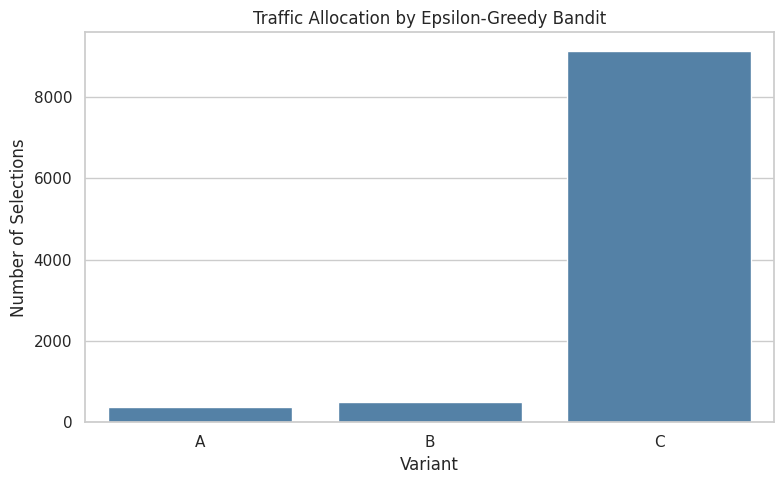

In [31]:
plt.figure(figsize=(8, 5))

sns.barplot(
    data=bandit_results,
    x="Variant",
    y="Selections",
    color="steelblue"
)

plt.xlabel("Variant")
plt.ylabel("Number of Selections")
plt.title("Traffic Allocation by Epsilon-Greedy Bandit")
plt.tight_layout()
plt.show()

### Analisis Multi-Arm Bandit

Variant C memiliki true click rate tertinggi, yaitu 5%. Setelah beberapa
rounds, algoritma lebih sering memilih Variant C.

Sebagian traffic tetap dialokasikan ke Variant A dan B karena epsilon
sebesar 0,1 mempertahankan proses exploration.

Multi-arm bandit dapat mengurangi opportunity cost selama eksperimen,
tetapi analisis inferensinya lebih kompleks karena alokasi sample
berubah secara adaptif.

## 13. Statistical Power and Sample Size

Statistical power adalah probabilitas menolak null hypothesis ketika
alternative hypothesis memang benar.

$$
Power=1-\beta
$$

Power dipengaruhi oleh:

1. Effect size.
2. Sample size.
3. Variasi data.
4. Alpha.
5. One-sided atau two-sided test.

Power yang umum digunakan adalah 0,80. Artinya, eksperimen mempunyai
peluang 80% mendeteksi effect sebesar target jika effect tersebut
benar-benar ada.

Effect yang kecil membutuhkan sample lebih besar agar dapat dibedakan
dari random variation.

In [32]:
baseline_rate = 0.011

target_rates = [
    0.0121,
    0.0165
]

power_analysis = NormalIndPower()

sample_size_results = []

for target_rate in target_rates:
    effect_size = (
        sm.stats.proportion_effectsize(
            target_rate,
            baseline_rate
        )
    )

    required_sample_size = (
        power_analysis.solve_power(
            effect_size=effect_size,
            alpha=0.05,
            power=0.80,
            ratio=1,
            alternative="larger"
        )
    )

    sample_size_results.append({
        "Baseline Rate":
            baseline_rate,
        "Target Rate":
            target_rate,
        "Absolute Effect":
            target_rate
            - baseline_rate,
        "Effect Size":
            effect_size,
        "Required Sample per Group":
            np.ceil(
                required_sample_size
            )
    })

sample_size_table = pd.DataFrame(
    sample_size_results
)

sample_size_table

,Baseline Rate,Target Rate,Absolute Effect,Effect Size,Required Sample per Group
0,0.0110,0.0121,0.0011,0.0103,"116,602.0000"
1,0.0110,0.0165,0.0055,0.0475,"5,488.0000"


### Analisis Power dan Sample Size

Peningkatan conversion rate dari 1,10% menjadi 1,21% hanya menghasilkan
absolute effect sebesar 0,11 percentage points. Untuk mendeteksi effect
sekecil ini dibutuhkan sekitar 116.602 observasi pada setiap kelompok.

Peningkatan dari 1,10% menjadi 1,65% mempunyai effect yang lebih besar,
sehingga kebutuhan sample turun menjadi sekitar 5.488 observasi per
kelompok.

Semakin kecil effect yang ingin dideteksi, semakin besar sample yang
dibutuhkan. Oleh karena itu, eksperimen sebaiknya menentukan minimum
practically important effect sebelum mengumpulkan data.

## 15. Kesimpulan

Pada Chapter 3, saya mempelajari bahwa eksperimen harus dirancang
sebelum data dianalisis. Control group, randomization, metric, arah
hypothesis, alpha, power, dan target effect harus ditentukan dengan
jelas.

Permutation test mengukur statistical significance melalui pengacakan
data dan membutuhkan sedikit asumsi distribusi. t-test memberikan
pendekatan parametrik untuk membandingkan dua mean. ANOVA digunakan
ketika jumlah kelompok lebih dari dua.

P-value bukan probabilitas bahwa null hypothesis benar. Hasil yang
signifikan secara statistik juga belum tentu penting secara praktis.
Effect size dan confidence interval harus dipertimbangkan bersama
p-value.

Chi-square dan Fisher's Exact Test digunakan untuk categorical data.
Multiple testing harus dikendalikan karena semakin banyak hypothesis
yang diuji, semakin besar kemungkinan false positive.

Multi-arm bandit dapat mengarahkan lebih banyak traffic ke treatment
yang lebih baik selama eksperimen. Power dan sample size analysis
memastikan eksperimen memiliki data yang cukup untuk mendeteksi effect
yang dianggap penting.

## 16. References

1. Bruce, P., Bruce, A., & Gedeck, P. (2020).
   *Practical Statistics for Data Scientists: 50+ Essential Concepts
   Using R and Python* (2nd ed.). O'Reilly Media.

2. Official Book Repository — Chapter 3.  
   https://github.com/gedeck/practical-statistics-for-data-scientists

3. SciPy Statistical Functions.  
   https://docs.scipy.org/doc/scipy/reference/stats.html

4. Statsmodels Documentation.  
   https://www.statsmodels.org/stable/

5. Pandas Documentation.  
   https://pandas.pydata.org/docs/

6. Matplotlib Documentation.  
   https://matplotlib.org/stable/

7. Seaborn Documentation.  
   https://seaborn.pydata.org/